# 2nd continuation of Transformer vs Linear Regression file 

### Time series with added information about t  
So, time series with when the points were measured. 
Time is added 
* as a concatenated vector, or
* as a positional encoding


Data:  $y(t) = \sin(t) + noise $ for $t = 0, 0.1, ..., 29.9, 30$

Goal: Train a model to predict $y_{t+1}$ given previous $N$ time steps, i.e.,

$[(t_{i-N}, y_{i-N}), ..., (t_i,y_i)]$ $\to$ $y(t_{i+1})$.

Compare:  MLP (simple feedforward),  Transformer (sequence model) and RNN

First approach - concatenate t and y histories to give MLP time-aware context.

MLP learns both temporal patterns and time-varying input dependencies.

Each sample is $[t_{i-N}, ..., t_i, y_{i-N}, ..., y_i] + t_{i+1}$ → $y_{i+1}$.


### How the data should be fed into the models:

Option 1: MLP (concatenated t, y)
You can concatenate past t and y, and also add $t_{n+1}$ as input to predict $y_{n+1}$.

Input:
$[t₁, ..., tₙ, y₁, ..., yₙ, t_{n+1}]$ → shape: (2 × window_size + 1,)

MLP Output:
Scalar prediction for $y_{n+1}$.

Option 2: RNN (sequence input), plus t_{n+1} input
Feed $[t₁, y₁], ..., [tₙ, yₙ]$ into RNN (shape: (seq_len, 2)).

After RNN processes the sequence, concatenate RNN output + $t_{n+1}$, then pass through a final layer.


## Load packages, generate data 

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split

In [654]:
#--- 1. Generate Sine Wave Data
t = np.arange(0, 30, 0.1)
y = np.sin(t) + 0.10* np.random.normal(0,1,len(t))

#--- Prepare sequences with fixed window size - X_seq[[0]] is y from 0 till 9, y_seq[0] is y[10] etc.
window_size = 50
X_list = []
y_list = []
for i in range(len(y) - window_size - 1):
    t_window = t[i:i+window_size]
    y_window = y[i:i+window_size]
    t_next = t[i+window_size]  # scalar
    y_next = y[i+window_size]  # scalar

    # Concatenate t_window, y_window, and t_next
    input_vector = np.concatenate([y_window, t_window, [t_next]])  # shape (2*window + 1,)
    X_list.append(input_vector)
    y_list.append(y_next)

X_list = np.array(X_list)  # shape (N, 2*window+1)
y_list = np.array(y_list)

# Convert to tensors
X_tensor = torch.tensor(X_list, dtype=torch.float32)
y_tensor = torch.tensor(y_list, dtype=torch.float32)

#--- Train/test split non-random
train_size = int(0.8 * len(X_tensor))
train_X, test_X = X_tensor[:train_size], X_tensor[train_size:]
train_y, test_y = y_tensor[:train_size], y_tensor[train_size:]

In [656]:
# train_X[0] has y0 - yi, t_0-t_i+1,  train_y[0] = y(t_i+1)
y[:window_size+1], t[:window_size+1], train_X[0],  train_y[0]

(array([-0.19223555,  0.05511451,  0.10386604,  0.3149726 ,  0.43885157,
         0.25982703,  0.60024282,  0.54733591,  0.67583007,  0.76392466,
         0.80542947,  0.77888274,  1.03021805,  0.93855396,  0.7106125 ,
         0.98186859,  0.92516885,  0.94318786,  0.91495367,  1.10027419,
         0.89557367,  0.93550297,  0.94809856,  0.61578643,  0.80349811,
         0.51549671,  0.7268876 ,  0.41295474,  0.19058241,  0.13736364,
         0.22050721, -0.05860102, -0.18620917, -0.12154603, -0.30170684,
        -0.27021435, -0.37728656, -0.50039881, -0.71052392, -0.73893159,
        -0.7707568 , -0.77388899, -0.99506035, -0.97216993, -0.92205021,
        -1.1134299 , -1.1161194 , -0.95585118, -0.96965271, -1.25960643,
        -1.03870509]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
        3.9, 4. , 4.1, 4.2, 

In [658]:
# different set up for RNN:
# Create sequences for training

X_seq1 = []
t_seq1 = []
y_seq1 = []
for i in range(len(y) - window_size - 1):
    y_window = y[i:i+window_size]
    t_window = t[i:i+window_size]
    t_next = t[i+window_size]  # time for y_{n+1}
    y_next = y[i+window_size]
    
    # Store sequence and prediction target
    X_seq1.append(np.stack([y_window, t_window], axis=1))  # shape (window_size, 2)
    t_seq1.append(t_next)
    y_seq1.append(y_next)

X_seq1 = np.array(X_seq1)        # shape (N, window_size, 2)
t_seq1 = np.array(t_seq1).reshape(-1, 1)  # shape (N, 1)
y_seq1 = np.array(y_seq1)

# Convert to tensors
X_tensor1 = torch.tensor(X_seq1, dtype=torch.float32)
t_tensor1 = torch.tensor(t_seq1, dtype=torch.float32)
y_tensor1 = torch.tensor(y_seq1, dtype=torch.float32)

train_X1, test_X1 = X_tensor1[:train_size], X_tensor1[train_size:]
train_t1, test_t1 = t_tensor1[:train_size], t_tensor1[train_size:]
train_y1, test_y1 = y_tensor1[:train_size], y_tensor1[train_size:]

In [660]:
# train_X1[0] has 2-dim array for y and t 0-i, train_t1[0] has next t_i+1, train_y1 = y_i+1
y[:window_size+1], t[:window_size+1], train_X1[0], train_t1[0], train_y1[0]

(array([-0.19223555,  0.05511451,  0.10386604,  0.3149726 ,  0.43885157,
         0.25982703,  0.60024282,  0.54733591,  0.67583007,  0.76392466,
         0.80542947,  0.77888274,  1.03021805,  0.93855396,  0.7106125 ,
         0.98186859,  0.92516885,  0.94318786,  0.91495367,  1.10027419,
         0.89557367,  0.93550297,  0.94809856,  0.61578643,  0.80349811,
         0.51549671,  0.7268876 ,  0.41295474,  0.19058241,  0.13736364,
         0.22050721, -0.05860102, -0.18620917, -0.12154603, -0.30170684,
        -0.27021435, -0.37728656, -0.50039881, -0.71052392, -0.73893159,
        -0.7707568 , -0.77388899, -0.99506035, -0.97216993, -0.92205021,
        -1.1134299 , -1.1161194 , -0.95585118, -0.96965271, -1.25960643,
        -1.03870509]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
        3.9, 4. , 4.1, 4.2, 

In [662]:
# for Transformer 
X_seq2 = []
y_seq2 = []
for i in range(len(y) - window_size - 1):
    t_window = t[i:i+window_size]
    y_window = y[i:i+window_size]
    t_next = t[i+window_size]  # scalar
    y_next = y[i+window_size]  # target

    # Build input sequence: [(t₁, y₁), ..., (tₙ, yₙ), (t_{n+1}, 0)]
    t_seq = np.append(t_window, t_next)         # shape (window+1,)
    y_seq_partial = np.append(y_window, 0.0)    # mask y_{n+1} as 0.0

    seq_input = np.stack([y_seq_partial, t_seq], axis=1)  # shape (window+1, 2)
    X_seq2.append(seq_input)
    y_seq2.append(y_next)

X_seq2 = np.array(X_seq2)   # shape (N, window+1, 2)
y_seq2 = np.array(y_seq2)

# Convert to torch tensors
X_tensor2 = torch.tensor(X_seq2, dtype=torch.float32)
y_tensor2 = torch.tensor(y_seq2, dtype=torch.float32)

train_X2, test_X2 = X_tensor2[:train_size], X_tensor2[train_size:]
train_y2, test_y2 = y_tensor2[:train_size], y_tensor2[train_size:]

In [664]:
# train_X2[0] has 2-dim array for y and t 0-i, train_t1[0] has next t_i+1, train_y1 = y_i+1
y[:window_size+1], t[:window_size+1], train_X2[0], train_y2[0]

(array([-0.19223555,  0.05511451,  0.10386604,  0.3149726 ,  0.43885157,
         0.25982703,  0.60024282,  0.54733591,  0.67583007,  0.76392466,
         0.80542947,  0.77888274,  1.03021805,  0.93855396,  0.7106125 ,
         0.98186859,  0.92516885,  0.94318786,  0.91495367,  1.10027419,
         0.89557367,  0.93550297,  0.94809856,  0.61578643,  0.80349811,
         0.51549671,  0.7268876 ,  0.41295474,  0.19058241,  0.13736364,
         0.22050721, -0.05860102, -0.18620917, -0.12154603, -0.30170684,
        -0.27021435, -0.37728656, -0.50039881, -0.71052392, -0.73893159,
        -0.7707568 , -0.77388899, -0.99506035, -0.97216993, -0.92205021,
        -1.1134299 , -1.1161194 , -0.95585118, -0.96965271, -1.25960643,
        -1.03870509]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
        3.9, 4. , 4.1, 4.2, 

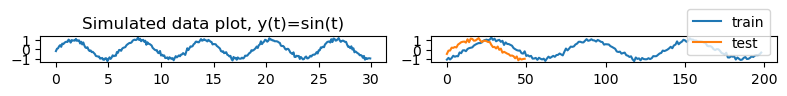

In [666]:
fig, axs = plt.subplots(1, 2, figsize=(8, 1))
axs[0].plot(t,y); axs[0].set_title("Simulated data plot, y(t)=sin(t)"); 
axs[1].plot(train_y, label = "train"); axs[1].plot(test_y, label = "test"); axs[1].legend()
plt.tight_layout()
plt.show()

## Models 

MLP Input:
$[t₁, ..., tₙ, y₁, ..., yₙ, t_{n+1}]$ → shape (2 × window_size + 1,)

In [670]:
# M1. Simple MLP Model
class MLPWithTime(nn.Module):
    def __init__(self, window_size):
        super().__init__()
        input_dim = 2 * window_size + 1
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x).squeeze(-1)

In [713]:
# M2. Transformer Model
class TransformerWithTime(nn.Module):
    def __init__(self, input_dim=2, d_model=64, nhead=1, num_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_layer = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (batch_size, seq_len, 2)
        x = self.input_proj(x)  # (batch_size, seq_len, d_model)
        x = self.transformer(x)  # (batch_size, seq_len, d_model)
        last_token = x[:, -1, :]  # Use the final token corresponding to t_{n+1}
        return self.output_layer(last_token).squeeze(-1)


In [674]:
# M3 RNN Model
class RNNWithTime(nn.Module):
    def __init__(self, input_size=2, hidden_size=32):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size + 1, 16)  # Add t_{n+1} to the input of final FC layer
        self.fc2 = nn.Linear(16, 1)  # Add t_{n+1} to the input of final FC layer
    def forward(self, seq, t_next):
        # seq: (batch, seq_len, 2), t_next: (batch, 1)
        out, _ = self.rnn(seq)
        last_out = out[:, -1, :]  # shape (batch, hidden_size)
        combined = torch.cat([last_out, t_next], dim=1)  # shape (batch, hidden + 1)
        x = F.relu(self.fc(combined)) # non-linear transformation
        return self.fc2(x).squeeze(-1)

RNN we  directly feed 2 features, while in MLP we give a series of concatenated t and yL

| Model Type | How it Processes Data                                        |
| ---------- | ------------------------------------------------------------ |
| **MLP**    | Processes input **as a flat vector** — no sequence awareness |
| **RNN**    | Processes input **as a sequence** — step-by-step over time   |


### Formula 
*for predicting $\hat{y}_{t+1}$** using both **$y$-history**, **$t$-history**, and **$t_{n+1}$** as input* .

#### Inputs:
* $\mathbf{y} = [y_{t-N}, y_{t-N+1}, \dots, y_t, 0.0]$
* $\mathbf{t} = [t_{t-N}, t_{t-N+1}, \dots, t_t, t_{t+1}]$

Input:
$$
\mathbf{x}_i = 
\begin{bmatrix}
y_i \\
t_i
\end{bmatrix}
\in \mathbb{R}^2, \quad i = t-N, \dots, t, t+1
$$

1. **Input projection:**

$$
\mathbf{z}_i = W_{\text{proj}} \cdot \mathbf{x}_i + \mathbf{b}_{\text{proj}} \in \mathbb{R}^{d_{\text{model}}}
$$

with $d_{\text{model}} = 64$, ${W_{\text{proj}}}$ is 64 x 2, $\mathbf{z}_i \in \mathbb{R}^{64}$

2. **Self-attention (1 layer, 1 head):**

Compute queries, keys, values for all $i$:

$$
\mathbf{q}_i = W^Q \mathbf{z}_i, \quad \mathbf{k}_j = W^K \mathbf{z}_j, \quad \mathbf{v}_j = W^V \mathbf{z}_j
$$

All $\mathbf{W^Q}$, $\mathbf{W^K}$, and $\mathbf{W^V}$ are 64 x 64. 

Attention scores:

$$
\alpha_{ij} = \frac{\mathbf{q}_i^\top \mathbf{k}_j}{\sqrt{d_{\text{model}}}}, \quad 
\text{softmax over } j
$$

Attention output for token $i$:

$$
\mathbf{h}_i = \sum_j \text{softmax}(\alpha_{ij}) \cdot \mathbf{v}_j
$$

3. **Feedforward for each token:**

$$
\mathbf{o}_i = W_2 \cdot \text{ReLU}(W_1 \cdot \mathbf{h}_i + \mathbf{b}_1) + \mathbf{b}_2
$$

$\mathbf{W_1,W_2}$ are 64 x 64. 

4. **Prediction from final token (corresponding to $t_{n+1}$):**

$$
\hat{y}_{t+1} = w_{\text{out}}^\top \mathbf{o}_{t+1} + b_{\text{out}} \quad \text{where } \mathbf{o}_{t+1} = \text{output of last token}
$$

Final functional form:

$$
\hat{y}_{t+1} = f_\theta\left( \left[ \begin{bmatrix} y_{t-N} \\ t_{t-N} \end{bmatrix}, \dots, \begin{bmatrix} y_t \\ t_t \end{bmatrix}, \begin{bmatrix} 0 \\ t_{t+1} \end{bmatrix} \right] \right)
$$

Where $f_\theta$ includes:

* input projection,
* self-attention,
* feedforward layers,
* final linear projection to scalar.\text{proj}} \in \mathbb{



## Train functions

In [679]:
# 4. Train Function
def train_model(model, train_loader, test_loader, epochs=100, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            pred = model(xb)
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        avg_train_loss = total_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)

        # Evaluate
        model.eval()
        with torch.no_grad():
            preds, targets = [], []
            for xb, yb in test_loader:
                pred = model(xb)
                preds.append(pred)
                targets.append(yb)
            preds = torch.cat(preds)
            targets = torch.cat(targets)
            test_loss = loss_fn(preds, targets).item()
            test_losses.append(test_loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Train Loss={avg_train_loss:.4f}, Test Loss={test_loss:.4f}")

    return train_losses, test_losses, preds, targets

In [681]:
def train_rnn(model, train_loader, test_loader, epochs=100, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for xb, tb, yb in train_loader:
            pred = model(xb, tb)
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        avg_train_loss = total_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)

        # Evaluate
        model.eval()
        with torch.no_grad():
            preds, targets = [], []
            for xb, tb, yb in test_loader:
                pred = model(xb, tb)
                preds.append(pred)
                targets.append(yb)
            preds = torch.cat(preds)
            targets = torch.cat(targets)
            test_loss = loss_fn(preds, targets).item()
            test_losses.append(test_loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Train Loss={avg_train_loss:.4f}, Test Loss={test_loss:.4f}")

    return train_losses, test_losses, preds, targets

## Test 

In [684]:
if window_size >50: 
    batch_size= 64
elif window_size > 30: 
    batch_size= 32
else: batch_size= 16

In [686]:
#--- MLP
train_loader = DataLoader(TensorDataset(train_X, train_y), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(test_X, test_y), batch_size=batch_size)

In [688]:
mlp = MLPWithTime(window_size = window_size)
mse0_mlp, mse_mlp, pred_mlp, tgt_mlp = train_model(mlp, train_loader, test_loader, epochs = 100, lr = 1e-2)

Epoch 0: Train Loss=3.9656, Test Loss=2.8401
Epoch 10: Train Loss=0.0153, Test Loss=0.0158
Epoch 20: Train Loss=0.0123, Test Loss=0.0610
Epoch 30: Train Loss=0.0185, Test Loss=0.0219
Epoch 40: Train Loss=0.0157, Test Loss=0.0212
Epoch 50: Train Loss=0.0107, Test Loss=0.0169
Epoch 60: Train Loss=0.0112, Test Loss=0.0204
Epoch 70: Train Loss=0.0145, Test Loss=0.0142
Epoch 80: Train Loss=0.0131, Test Loss=0.0190
Epoch 90: Train Loss=0.0187, Test Loss=0.0252


In [689]:
#--- RNN
train_loader1 = DataLoader(TensorDataset(train_X1, train_t1, train_y1), batch_size=batch_size, shuffle=True)
test_loader1 = DataLoader(TensorDataset(test_X1, test_t1, test_y1), batch_size=batch_size)

In [690]:
rnn = RNNWithTime()
mse0_rnn, mse_rnn, pred_rnn, tgt_rnn = train_rnn(rnn, train_loader1, test_loader1, epochs = 100, lr = 1e-2)


Epoch 0: Train Loss=0.5363, Test Loss=0.8666
Epoch 10: Train Loss=0.0253, Test Loss=0.0579
Epoch 20: Train Loss=0.0222, Test Loss=0.0332
Epoch 30: Train Loss=0.0186, Test Loss=0.0328
Epoch 40: Train Loss=0.0247, Test Loss=0.0427
Epoch 50: Train Loss=0.0170, Test Loss=0.0481
Epoch 60: Train Loss=0.0213, Test Loss=0.0334
Epoch 70: Train Loss=0.0195, Test Loss=0.0292
Epoch 80: Train Loss=0.0189, Test Loss=0.0441
Epoch 90: Train Loss=0.0153, Test Loss=0.0598


In [691]:
# Stack y_hist and t_hist → shape (N, 2)
seq_input = np.stack([y_hist, t_hist], axis=1)  # shape (N, 2)

# Convert to tensor → add batch dimension → (1, N, 2)
seq_tensor = torch.tensor(seq_input, dtype=torch.float32).unsqueeze(0)  # (1, N, 2)

# Convert t_next to tensor → shape (1, 1)
t_next_tensor = torch.tensor([[t_next]], dtype=torch.float32)  # (1, 1)

# Model prediction
rnn.eval()
with torch.no_grad():
    y_next_pred = rnn(seq_tensor, t_next_tensor)  # Output: (1,)

y_next_pred

tensor([-0.8530])

In [715]:
#--- Transformer
train_loader2 = DataLoader(TensorDataset(train_X2,  train_y2), batch_size=batch_size, shuffle=True)
test_loader2 = DataLoader(TensorDataset(test_X2,  test_y2), batch_size=batch_size)

In [717]:
transformer = TransformerWithTime()
mse0_trans,mse_trans, pred_trans, tgt_rnn = train_model(
    transformer, train_loader2, test_loader2, epochs = 100, lr = 1e-3)

Epoch 0: Train Loss=2.2201, Test Loss=0.5233
Epoch 10: Train Loss=0.4881, Test Loss=0.5420
Epoch 20: Train Loss=0.3956, Test Loss=0.7563
Epoch 30: Train Loss=0.1452, Test Loss=0.2188
Epoch 40: Train Loss=0.1339, Test Loss=0.1606
Epoch 50: Train Loss=0.0608, Test Loss=0.1994
Epoch 60: Train Loss=0.0536, Test Loss=0.0663
Epoch 70: Train Loss=0.0384, Test Loss=0.0408
Epoch 80: Train Loss=0.1003, Test Loss=0.0751
Epoch 90: Train Loss=0.0553, Test Loss=0.0323


## Generate future predictions 

In [696]:
# MLP:  input_vector = np.concatenate([y_window, t_window, [t_next]])  # shape (2*window + 1,)
# RNN:   X_seq1.append(np.stack([y_window, t_window], axis=1))  # shape (window_size, 2)
#       and  t_next
# Transformer:     seq_input = np.stack([y_seq_partial, t_seq], axis=1)  # shape (window+1, 2)

def generate_predictions(model, t_hist, y_hist, t_future, model_type="MLP"):
    """      model: trained model
    t_hist: np.array of shape (window_size,) 
    y_hist: np.array of shape (window_size,)
    t_future: np.array of shape (future_steps,)
    model_type: "MLP", "RNN", "Transformer"
    """
    model.eval()
    preds = []
    y_curr = y_hist.copy()
    t_curr = t_hist.copy()
    for t_next in t_future:
        if model_type == "MLP":
            input_vec = np.concatenate([y_curr, t_curr, [t_next]])  # shape (2*window + 1,)
            input_tensor = torch.tensor(input_vec, dtype=torch.float32).unsqueeze(0)  # (1, dim)
            with torch.no_grad():
                y_pred = model(input_tensor).item()
        elif model_type == "RNN":
            input_seq = np.stack([y_curr, t_curr], axis=1)  # (window_size, 2)
            input_tensor = torch.tensor(input_seq, dtype=torch.float32).unsqueeze(0)  # (1, window, 2)
            #convert t_next to tensor shape (1,1)
            t_next_tensor = torch.tensor([[t_next]], dtype = torch.float32) # (1,1)
            with torch.no_grad():
                y_pred = model(input_tensor, t_next_tensor).item()
        elif model_type == "Transformer":
            # Build sequence with (t_next, 0) at end
            t_seq = np.append(t_curr, t_next)
            y_seq = np.append(y_curr, 0.0)
            input_seq = np.stack([y_seq, t_seq], axis=1)  # (window+1, 2)
            input_tensor = torch.tensor(input_seq, dtype=torch.float32).unsqueeze(0)  # (1, window+1, 2)
            with torch.no_grad():
                y_pred = model(input_tensor).item()
        else:
            raise ValueError("Unknown model_type")
        preds.append(y_pred)         # Save prediction
        t_curr = np.append(t_curr[1:], t_next)# Update history 
        y_curr = np.append(y_curr[1:], y_pred)

    return np.array(preds)


In [698]:
# Predict the next 50 steps after start_n for a single start_n

def generate_from_start_n(start_n = 100, future_steps = 50, t_future = 0):
    
    # if no t_hist, we take 
    t_hist = t[start_n-window_size : start_n]
    y_hist = y[start_n-window_size: start_n]

    # Generate t_future for next 50 time points (based on spacing)
    if (t_future == 0):      
        t_future = t[start_n : start_n  + future_steps]

    # Generate predictions
    preds_mlp = generate_predictions(mlp, t_hist, y_hist, t_future, model_type="MLP")
    preds_trf = generate_predictions(transformer, t_hist, y_hist, t_future, model_type="Transformer")
    preds_rnn = generate_predictions(rnn, t_hist, y_hist, t_future, model_type="RNN")
    
    return preds_mlp, preds_trf, preds_rnn, t_future


## Check if generated trajectories make sense: even $t_{future}$

### Window size = 15

In [719]:
# loop for several starting points 
start_ns = [50, 110, 160, 210 ,220]
future_steps = 50
a1 = []; a2 = []; a3 = []; t_fut = []
for start_n in start_ns:
    temp = generate_from_start_n(start_n)
    a1.append(temp[0])
    a2.append(temp[1])
    a3.append(temp[2])
    t_fut.append(temp[3])

Window size = 1.5


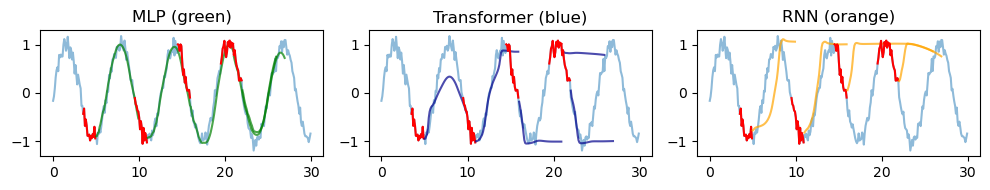

In [644]:
# window size = 15 steps  * 0.1 step size = 1.5
# plot predictions 

print( f"Window size = {window_size*0.1}")
fig, axs = plt.subplots(1, 3, figsize=(10, 2))
#axs[0].set_title("Generated future trajectories, mlp(green), transformer(blue), RNN (orange)")

axs[0].set_title("MLP (green)")
axs[1].set_title("Transformer (blue)")
axs[2].set_title("RNN (orange)")

axs[0].plot(t,y, alpha = 0.5) # the initial sequence
axs[1].plot(t,y, alpha = 0.5) # the initial sequence
axs[2].plot(t,y, alpha = 0.5) # the initial sequence

for i in range(len(start_ns)):
    axs[0].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[0].plot(t[start_ns[i]: start_ns[i] + future_steps], a1[i], color = "green", alpha = 0.7)   
    axs[1].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[1].plot(t[start_ns[i]: start_ns[i] + future_steps], a2[i], color = "darkblue", alpha = 0.7)   
    axs[2].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[2].plot(t[start_ns[i]: start_ns[i] + future_steps], a3[i], color = "orange", alpha = 0.7)   

plt.tight_layout()

plt.show()

### Window_size = 30

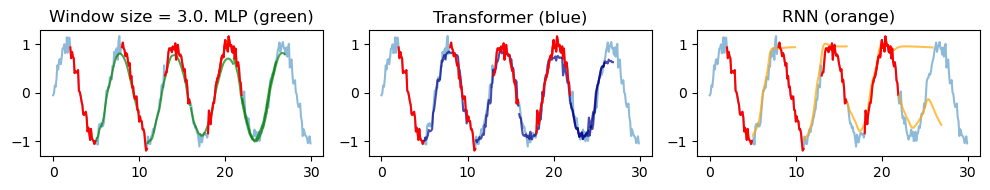

In [494]:
# window size = 30 steps  * 0.1 step size = 3.0
# plot predictions 
fig, axs = plt.subplots(1, 3, figsize=(10, 2))
#axs[0].set_title("Generated future trajectories, mlp(green), transformer(blue), RNN (orange)")
axs[0].set_title(f"Window size = {window_size*0.1}. MLP (green)")
axs[1].set_title("Transformer (blue)")
axs[2].set_title("RNN (orange)")
axs[0].plot(t,y, alpha = 0.5)
axs[1].plot(t,y, alpha = 0.5)
axs[2].plot(t,y, alpha = 0.5)
for i in range(len(start_ns)):
    axs[0].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[0].plot(t[start_ns[i]: start_ns[i] + future_steps], a1[i], color = "green", alpha = 0.7)   
    axs[1].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[1].plot(t[start_ns[i]: start_ns[i] + future_steps], a2[i], color = "darkblue", alpha = 0.7)   
    axs[2].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[2].plot(t[start_ns[i]: start_ns[i] + future_steps], a3[i], color = "orange", alpha = 0.7)   
plt.tight_layout()
plt.show()

### Window_size = 50

Window size = (5.0, 50)


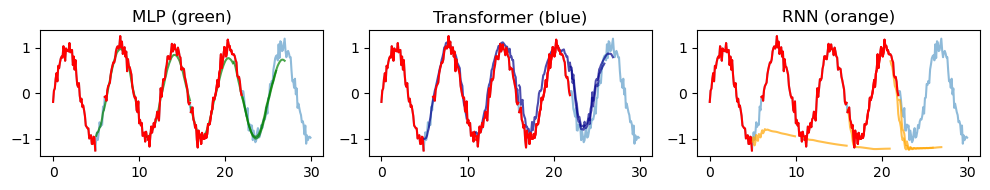

In [723]:
# window size = 50
# plot predictions 
print( f"Window size = {window_size*0.1, window_size}")
fig, axs = plt.subplots(1, 3, figsize=(10, 2))
#axs[0].set_title("Generated future trajectories, mlp(green), transformer(blue), RNN (orange)")
axs[0].set_title("MLP (green)")
axs[1].set_title("Transformer (blue)")
axs[2].set_title("RNN (orange)")
axs[0].plot(t,y, alpha = 0.5)
axs[1].plot(t,y, alpha = 0.5)
axs[2].plot(t,y, alpha = 0.5)
for i in range(len(start_ns)):
    axs[0].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[0].plot(t[start_ns[i]: start_ns[i] + future_steps], a1[i], color = "green", alpha = 0.7)   
    axs[1].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[1].plot(t[start_ns[i]: start_ns[i] + future_steps], a2[i], color = "darkblue", alpha = 0.7)   
    axs[2].plot(t[start_ns[i]-window_size:start_ns[i]], y[start_ns[i]-window_size:start_ns[i]], color = "red")
    axs[2].plot(t[start_ns[i]: start_ns[i] + future_steps], a3[i], color = "orange", alpha = 0.7)   
plt.tight_layout()
plt.show()

## Check if generated trajectories make sense: any $t_{fut}$ (if sine truely learnt)

In [843]:
# reminder: 
# t = np.arange(0, 30, 0.1)
# y = np.sin(t) + 0.10* np.random.normal(0,1,len(t))

start_n = 100
t_hist = t[start_n-window_size : start_n]
y_hist = y[start_n-window_size: start_n]
t[start_n], np.sin(t[start_n]), y[start_n]
t_future = np.arange(t[start_n],t[start_n]+10, 0.2)

p1 = generate_predictions(mlp, t_hist, y_hist, t_future, model_type="MLP")
p2 = generate_predictions(transformer, t_hist, y_hist, t_future, model_type="Transformer")


In [845]:
np.round(p1[:9],2)

array([-0.53, -0.59, -0.68, -0.74, -0.81, -0.86, -0.88, -0.93, -0.93])

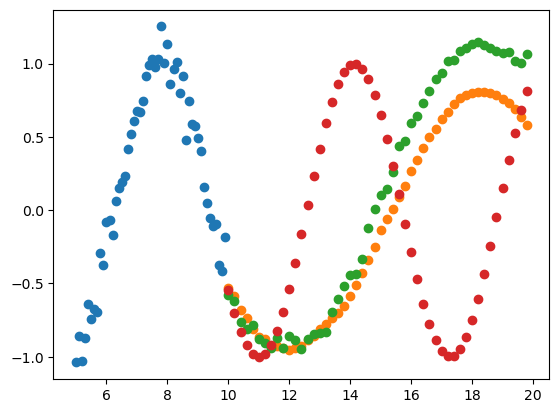

In [847]:
plt.scatter(t_hist, y_hist)
plt.scatter(t_future, p1)
plt.scatter(t_future, p2)
plt.scatter(t_future, np.sin(t_future))

$=>$ No, it does not care about $t$ at all, predicts the same.

Perhaps, it could not learn from evenly spread $t$s that ts matter anything

Need to check if training on uneven would make a difference, or supplying $t$s as position encodings